In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import griddata
#step1 load data
in2d_01=np.loadtxt('./01_ILP_exp/in_2d')
in1d_01=np.loadtxt('./01_ILP_exp/in_1d')
out2d_01=np.loadtxt('./01_ILP_exp/out_2d')
out1d_01=np.loadtxt('./01_ILP_exp/out_1d')

in2d_02=np.loadtxt('./02_ILP_ter/in_2d')
in1d_02=np.loadtxt('./02_ILP_ter/in_1d')
out2d_02=np.loadtxt('./02_ILP_ter/out_2d')
out1d_02=np.loadtxt('./02_ILP_ter/out_1d')

in2d_03=np.loadtxt('./03_drip_Extep/in_2d')
in1d_03=np.loadtxt('./03_drip_Extep/in_1d')
out2d_03=np.loadtxt('./03_drip_Extep/out_2d')
out1d_03=np.loadtxt('./03_drip_Extep/out_1d')

in2d_04=np.loadtxt('./04_drip_tersoff/in_2d')
in1d_04=np.loadtxt('./04_drip_tersoff/in_1d')
out2d_04=np.loadtxt('./04_drip_tersoff/out_2d')
out1d_04=np.loadtxt('./04_drip_tersoff/out_1d')

in2d_05=np.loadtxt('./LDA/in_2d')
in1d_05=np.loadtxt('./LDA/in_1d')
out2d_05=np.loadtxt('./LDA/out_2d')
out1d_05=np.loadtxt('./LDA/out_1d')

In [2]:
a=15.237320138397038
lat = a*np.array([[1,0],[0.5,np.sqrt(3)/2]])
def repeat(x,y,z,m1,m2,tt):
    tax=[]
    tay=[]
    taz=[]
    for i in range(-m1,m2):
        for j in range(-m1,m2):
            tax=np.append(tax,x+i*tt[0,0]+j*tt[1,0])
            tay=np.append(tay,y+i*tt[0,1]+j*tt[1,1])
            taz=np.append(taz,z+np.array(0))
    tax=np.array(tax)
    tay=np.array(tay)
    taz=np.array(taz)
    pos=np.array([tax,tay,taz]).T
    return pos
num = 500
a1 = np.linspace(0,1,num)
a2 = np.linspace(0,1,num)
a1,a2=np.meshgrid(a1,a2)
XY=np.outer(a1.flatten(),lat[0])+np.outer(a2.flatten(),lat[1])
X=XY[:,0]
Y=XY[:,1]


In [3]:
print(np.max(in2d_01),np.min(in2d_01))
print(np.max(in2d_02),np.min(in2d_02))
print(np.max(in2d_03),np.min(in2d_03))
print(np.max(in2d_04),np.min(in2d_04))
print(np.max(in2d_05),np.min(in2d_05))
# print(np.max(in2d_06),np.min(in2d_06))
# print(np.max(in2d_07),np.min(in2d_07))
inmax=np.max(in2d_02)
inmin=0.0




1.3008190922135323 3.4059234665185114e-08
1.3012428434917571 6.180843856412838e-08
1.3006835984880594 7.300064320651543e-08
1.3010323762066365 1.19089676049767e-07
1.3001729247626825 0.0


In [4]:
print(np.max(out2d_01),np.min(out2d_01))
print(np.max(out2d_02),np.min(out2d_02))
print(np.max(out2d_03),np.min(out2d_03))
print(np.max(out2d_04),np.min(out2d_04))
print(np.max(out2d_05),np.min(out2d_05))
# print(np.max(out2d_06),np.min(out2d_06))
# print(np.max(out2d_07),np.min(out2d_07))
outmax=np.max(out2d_03)
outmin=np.min(out2d_01)


3.4948941506507394 3.241064988490937
3.474356678189123 3.2610980636312665
3.512953492892771 3.291079415447198
3.497839404658873 3.311755397053144
3.477650522447828 3.2780081993320365


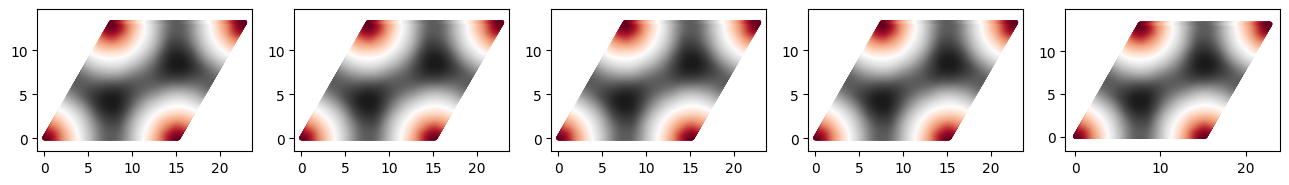

In [51]:
plt.figure(figsize=(13,2))
plt.subplot(1,5,1)
plt.scatter(X,Y,c=in2d_01,s=10,cmap='RdGy',edgecolor='none',vmax=inmax,vmin=inmin)
plt.axis('equal')
plt.tight_layout()
plt.subplot(1,5,2)
plt.scatter(X,Y,c=in2d_02,s=10,cmap='RdGy',edgecolor='none',vmax=inmax,vmin=inmin)
plt.axis('equal')
plt.tight_layout()
plt.subplot(1,5,3)
plt.scatter(X,Y,c=in2d_03,s=10,cmap='RdGy',edgecolor='none',vmax=inmax,vmin=inmin)
plt.axis('equal')
plt.tight_layout()
plt.subplot(1,5,4)
plt.scatter(X,Y,c=in2d_04,s=10,cmap='RdGy',edgecolor='none',vmax=inmax,vmin=inmin)
plt.axis('equal')
plt.tight_layout()
plt.subplot(1,5,5)
plt.scatter(X,Y,c=in2d_05,s=10,cmap='RdGy',edgecolor='none',vmax=inmax,vmin=inmin)
plt.axis('equal')
plt.tight_layout()
plt.savefig('in3d')
# plt.subplot(1,7,6)
# plt.scatter(X,Y,c=in2d_06,s=10,cmap='RdGy',edgecolor='none',vmax=inmax,vmin=inmin)
# plt.axis('equal')
# plt.tight_layout()
# plt.subplot(1,7,7)
# plt.scatter(X,Y,c=in2d_07,s=10,cmap='RdGy',edgecolor='none',vmax=inmax,vmin=inmin)
# plt.axis('equal')
# plt.tight_layout()
# plt.colorbar()


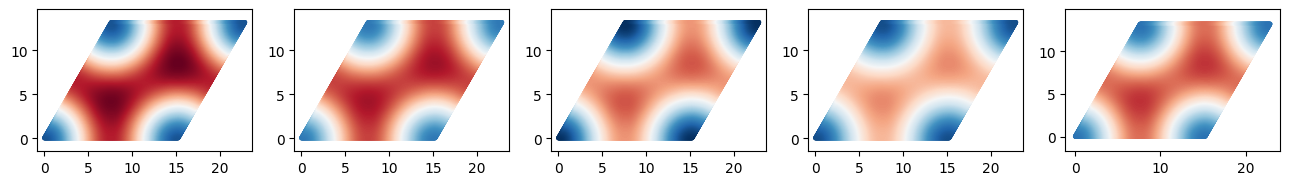

In [50]:
plt.figure(figsize=(13,2))
plt.subplot(1,5,1)
plt.scatter(X,Y,c=out2d_01,s=10,cmap='RdBu',edgecolor='none',vmax=outmax,vmin=outmin)
plt.axis('equal')
plt.tight_layout()
plt.subplot(1,5,2)
plt.scatter(X,Y,c=out2d_02,s=10,cmap='RdBu',edgecolor='none',vmax=outmax,vmin=outmin)
plt.axis('equal')
plt.tight_layout()
plt.subplot(1,5,3)
plt.scatter(X,Y,c=out2d_03,s=10,cmap='RdBu',edgecolor='none',vmax=outmax,vmin=outmin)
plt.axis('equal')
plt.tight_layout()
plt.subplot(1,5,4)
plt.scatter(X,Y,c=out2d_04,s=10,cmap='RdBu',edgecolor='none',vmax=outmax,vmin=outmin)
plt.axis('equal')
plt.tight_layout()
plt.subplot(1,5,5)
plt.scatter(X,Y,c=out2d_05,s=10,cmap='RdBu',edgecolor='none',vmax=outmax,vmin=outmin)
plt.axis('equal')
plt.tight_layout()
# plt.subplot(1,7,6)
# plt.scatter(X,Y,c=out2d_06,s=10,cmap='RdBu',edgecolor='none',vmax=outmax,vmin=outmin)
# plt.axis('equal')
# plt.tight_layout()
# plt.subplot(1,7,7)
# plt.scatter(X,Y,c=out2d_07,s=10,cmap='RdBu',edgecolor='none',vmax=outmax,vmin=outmin)
# plt.axis('equal')
# plt.tight_layout()
# plt.colorbar()
plt.savefig('out3d')


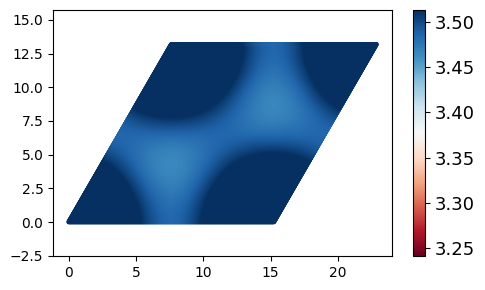

In [74]:
plt.figure(figsize=(5,3))
# Display the data with a colormap
cax = plt.scatter(X,Y,c=out2d_07,s=10,cmap='RdBu',edgecolor='none',vmax=outmax,vmin=outmin)
# Add a colorbar to the plot
cbar = plt.colorbar(cax)
# Set the font size for the colorbar ticks
cbar.ax.tick_params(labelsize=13)
plt.axis('equal')
plt.tight_layout()
# plt.colorbar()
plt.savefig('out')

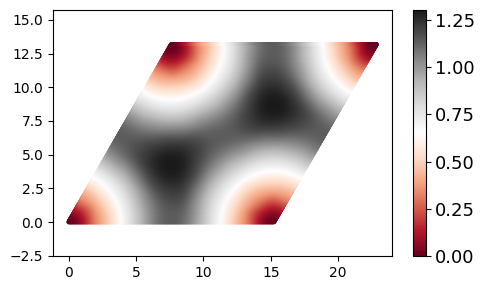

In [75]:
plt.figure(figsize=(5,3))
# Display the data with a colormap
cax = plt.scatter(X,Y,c=in2d_07,s=10,cmap='RdGy',edgecolor='none',vmax=inmax,vmin=inmin)
# Add a colorbar to the plot
cbar = plt.colorbar(cax)
# Set the font size for the colorbar ticks
cbar.ax.tick_params(labelsize=13)
plt.axis('equal')
plt.tight_layout()
# plt.colorbar()
plt.savefig('in')

In [27]:
stack=(0,abs(in1d_01).shape[0]/3,2*abs(in1d_01.shape[0])/3,abs(in1d_01.shape[0]))
stack2=(0,abs(out1d_01).shape[0]/3,2*abs(out1d_01.shape[0])/3,abs(out1d_01.shape[0]))

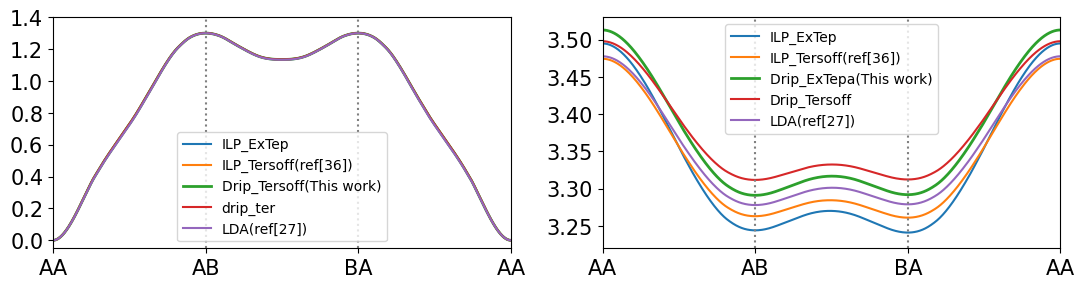

In [76]:
sss=15
plt.figure(figsize=(13,3))
plt.subplot(121)
plt.plot(abs(in1d_01),label='ILP_ExTep')
plt.plot(abs(in1d_02),label='ILP_Tersoff(ref[36])')
plt.plot(abs(in1d_03),label='Drip_Tersoff(This work)',lw=2)
plt.plot(abs(in1d_04),label='drip_ter')
plt.plot(abs(in1d_05),label='LDA(ref[27])')
plt.xticks(stack,('AA','AB','BA','AA'),fontsize=sss)
plt.xlim(0,abs(in1d_01).shape[0])
plt.ylim(-0.05,1.4)
plt.vlines(abs(in1d_01).shape[0]/3,-0.05,1.4,colors='grey',linestyles='dotted')
plt.vlines(2*abs(in1d_01).shape[0]/3,-0.05,1.4,colors='grey',linestyles='dotted')
plt.yticks(fontsize=sss)
# plt.plot(abs(in1d_06),label='PBE_V2')
# plt.plot(abs(in1d_07),label='PBE_V3')
# plt.ylim(1.1,1.26)
plt.yticks(fontsize=sss)
plt.legend()
plt.subplot(122)
plt.plot(abs(out1d_01),label='ILP_ExTep')
plt.plot(abs(out1d_02),label='ILP_Tersoff(ref[36])')
plt.plot(abs(out1d_03),label='Drip_ExTepa(This work)',lw=2)
plt.plot(abs(out1d_04),label='Drip_Tersoff')
plt.plot(abs(out1d_05),label='LDA(ref[27])')
plt.xticks(stack2,('AA','AB','BA','AA'),fontsize=sss)
# plt.plot(abs(out1d_06),label='PBE_V2')
# plt.plot(abs(out1d_07),label='PBE_V3')
plt.xlim(0,abs(out1d_01).shape[0])
plt.ylim(3.22,3.53)
plt.vlines(abs(out1d_01).shape[0]/3,3.22,3.53,colors='grey',linestyles='dotted')
plt.vlines(2*abs(out1d_01).shape[0]/3,3.22,3.53,colors='grey',linestyles='dotted')
plt.yticks(fontsize=sss)
plt.ylabel(r'$d_{ij}^{z}$')
plt.legend()
plt.savefig('inout1d')

